# Lab 2: Data Cleaning, Preprocessing, and Visualization
## Objective
Perform data cleaning, preprocessing, and visualization to prepare datasets for machine learning tasks.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load and Explore Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (210, 8)

First 5 rows:


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length_of_kernel         210 non-null    float64
 4   Width_of_kernel          210 non-null    float64
 5   Asymmetry_coefficient    210 non-null    float64
 6   Length_of_kernel_groove  210 non-null    float64
 7   Class                    210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [4]:
df.describe()

,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,Class
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


## 3. Data Cleaning

### 3.1 Missing Values

Missing values per column:
Area                       0
Perimeter                  0
Compactness                0
Length_of_kernel           0
Width_of_kernel            0
Asymmetry_coefficient      0
Length_of_kernel_groove    0
Class                      0
dtype: int64

Total missing values: 0


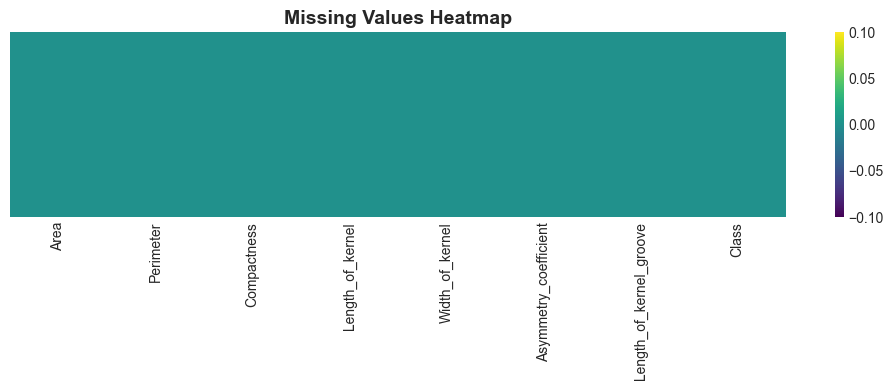


✅ No missing values found in the dataset.


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ No missing values found in the dataset.")

### 3.2 Duplicate Detection

In [6]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"Shape after removing duplicates: {df.shape}")
else:
    print("✅ No duplicate rows found.")

Number of duplicate rows: 0
✅ No duplicate rows found.


### 3.3 Outlier Detection

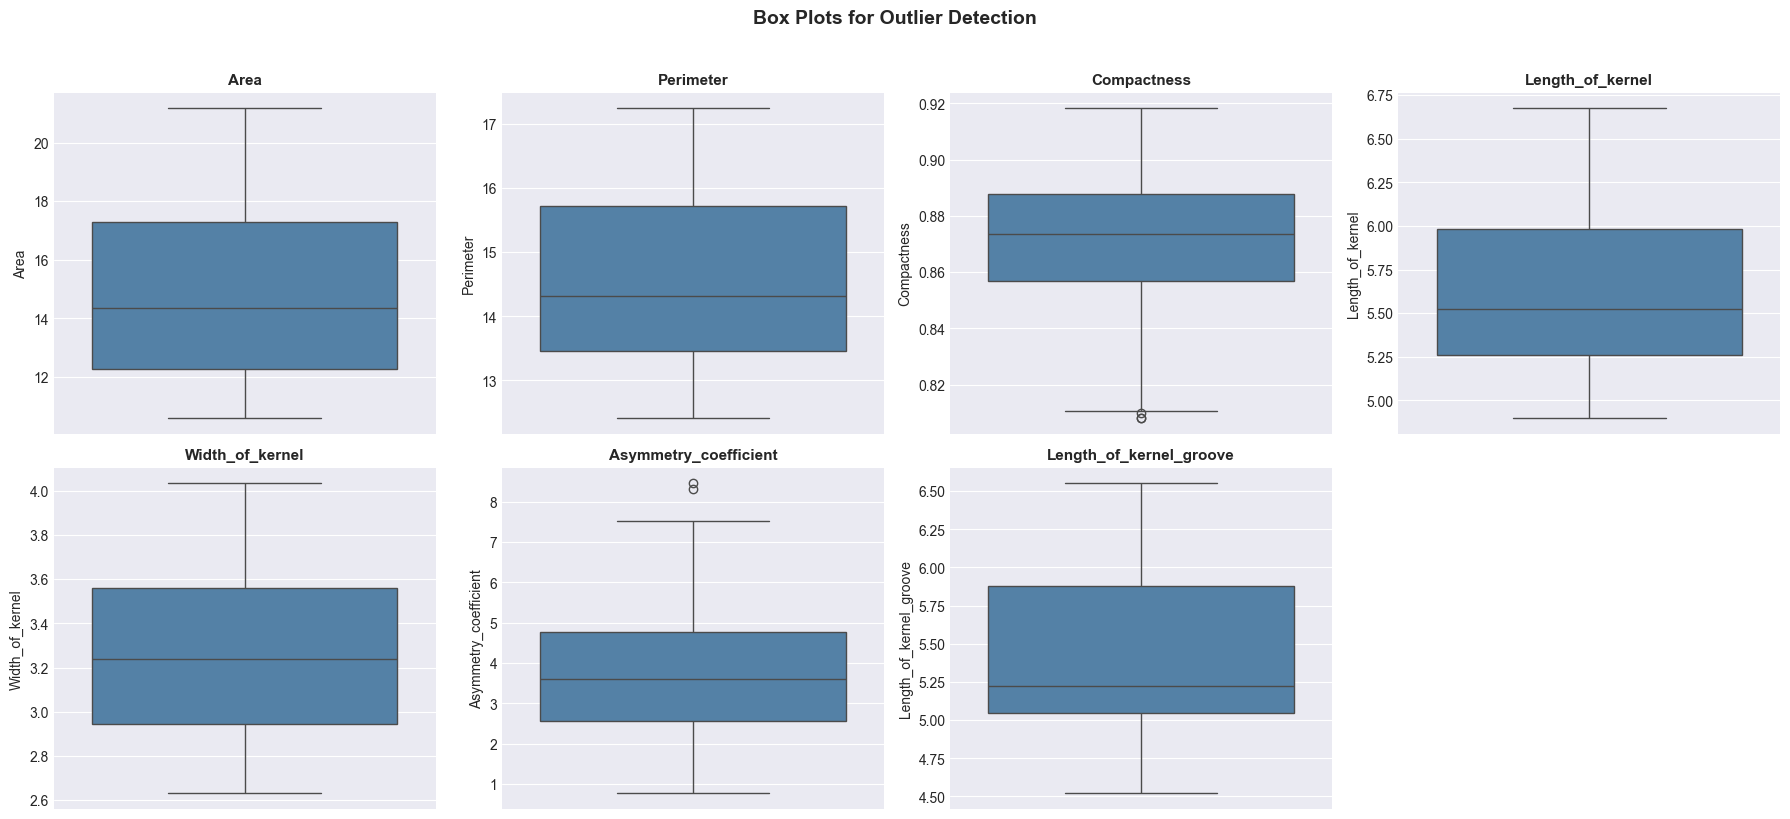

In [7]:
# Box plots to detect outliers
feature_cols = df.columns[:-1]  # All except 'Class'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')

# Remove empty subplot
axes[-1].set_visible(False)

plt.suptitle('Box Plots for Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# IQR method for outlier detection
print("Outlier count per feature (IQR method):")
print("=" * 45)

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col:30s}: {len(outliers)} outliers")

Outlier count per feature (IQR method):
Area                          : 0 outliers
Perimeter                     : 0 outliers
Compactness                   : 3 outliers
Length_of_kernel              : 0 outliers
Width_of_kernel               : 0 outliers
Asymmetry_coefficient         : 2 outliers
Length_of_kernel_groove       : 0 outliers


### 3.4 Data Type Validation

In [9]:
# Validate data types
print("Data Types:")
print(df.dtypes)

# Ensure Class is integer type
df['Class'] = df['Class'].astype(int)
print(f"\n✅ Class column type: {df['Class'].dtype}")
print(f"Unique classes: {sorted(df['Class'].unique())}")

Data Types:
Area                       float64
Perimeter                  float64
Compactness                float64
Length_of_kernel           float64
Width_of_kernel            float64
Asymmetry_coefficient      float64
Length_of_kernel_groove    float64
Class                        int64
dtype: object

✅ Class column type: int64
Unique classes: [np.int64(1), np.int64(2), np.int64(3)]


## 4. Data Preprocessing

### 4.1 Feature Scaling — StandardScaler (Z-score Normalization)

In [10]:
X = df[feature_cols]
y = df['Class']

# StandardScaler
scaler_standard = StandardScaler()
X_standard = pd.DataFrame(scaler_standard.fit_transform(X), columns=feature_cols)

print("After Standard Scaling (mean ≈ 0, std ≈ 1):")
X_standard.describe().loc[['mean', 'std']]

After Standard Scaling (mean ≈ 0, std ≈ 1):


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
mean,-3.383537e-16,1.184238e-16,1.285744e-15,-2.097793e-15,-3.383537e-16,-3.383537e-16,-8.987520e-17
std,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00


### 4.2 Feature Scaling — MinMaxScaler (Min-Max Normalization)

In [11]:
# MinMaxScaler
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), columns=feature_cols)

print("After Min-Max Scaling (range [0, 1]):")
X_minmax.describe().loc[['min', 'max']]

After Min-Max Scaling (range [0, 1]):


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 4.3 Comparison: Before and After Scaling

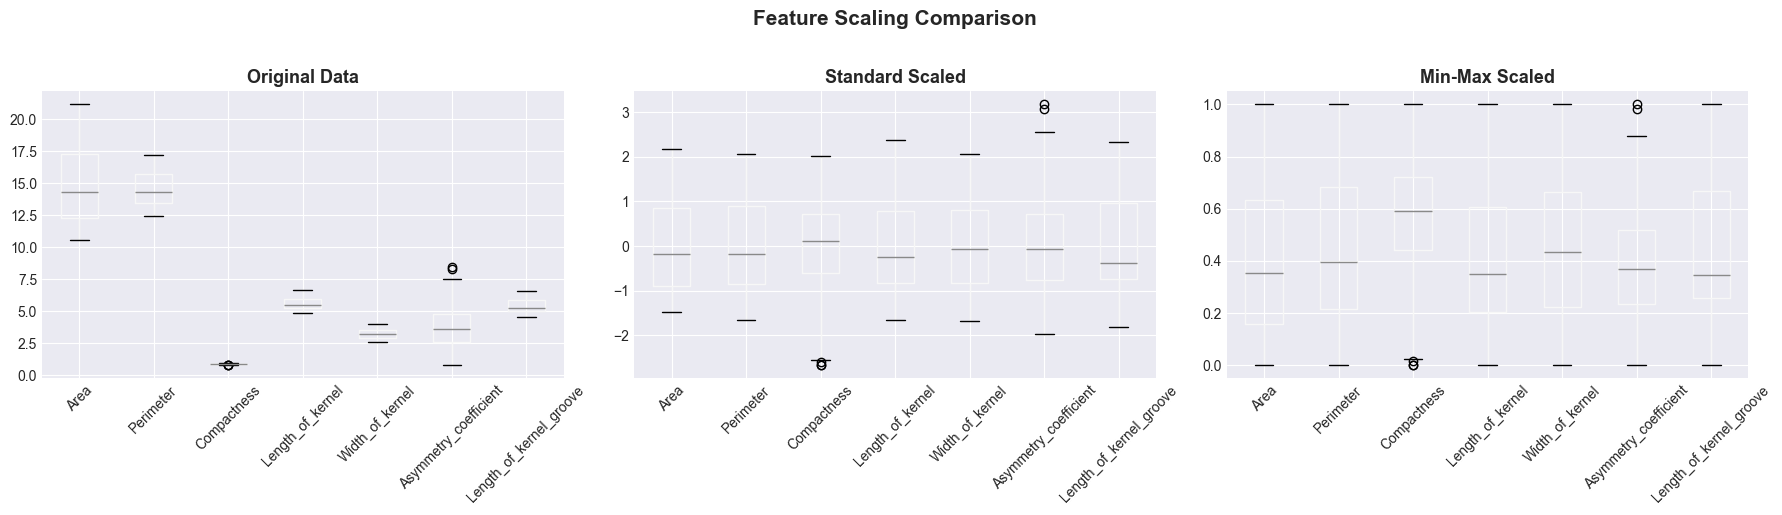

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
X.boxplot(ax=axes[0], rot=45)
axes[0].set_title('Original Data', fontsize=13, fontweight='bold')

# Standard Scaled
X_standard.boxplot(ax=axes[1], rot=45)
axes[1].set_title('Standard Scaled', fontsize=13, fontweight='bold')

# MinMax Scaled
X_minmax.boxplot(ax=axes[2], rot=45)
axes[2].set_title('Min-Max Scaled', fontsize=13, fontweight='bold')

plt.suptitle('Feature Scaling Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_standard, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training set: 168 samples
Testing set:  42 samples

Training class distribution:
Class
1    56
2    56
3    56
Name: count, dtype: int64

Testing class distribution:
Class
1    14
2    14
3    14
Name: count, dtype: int64


## 5. Data Visualization

### 5.1 Distribution of Features (Histograms)

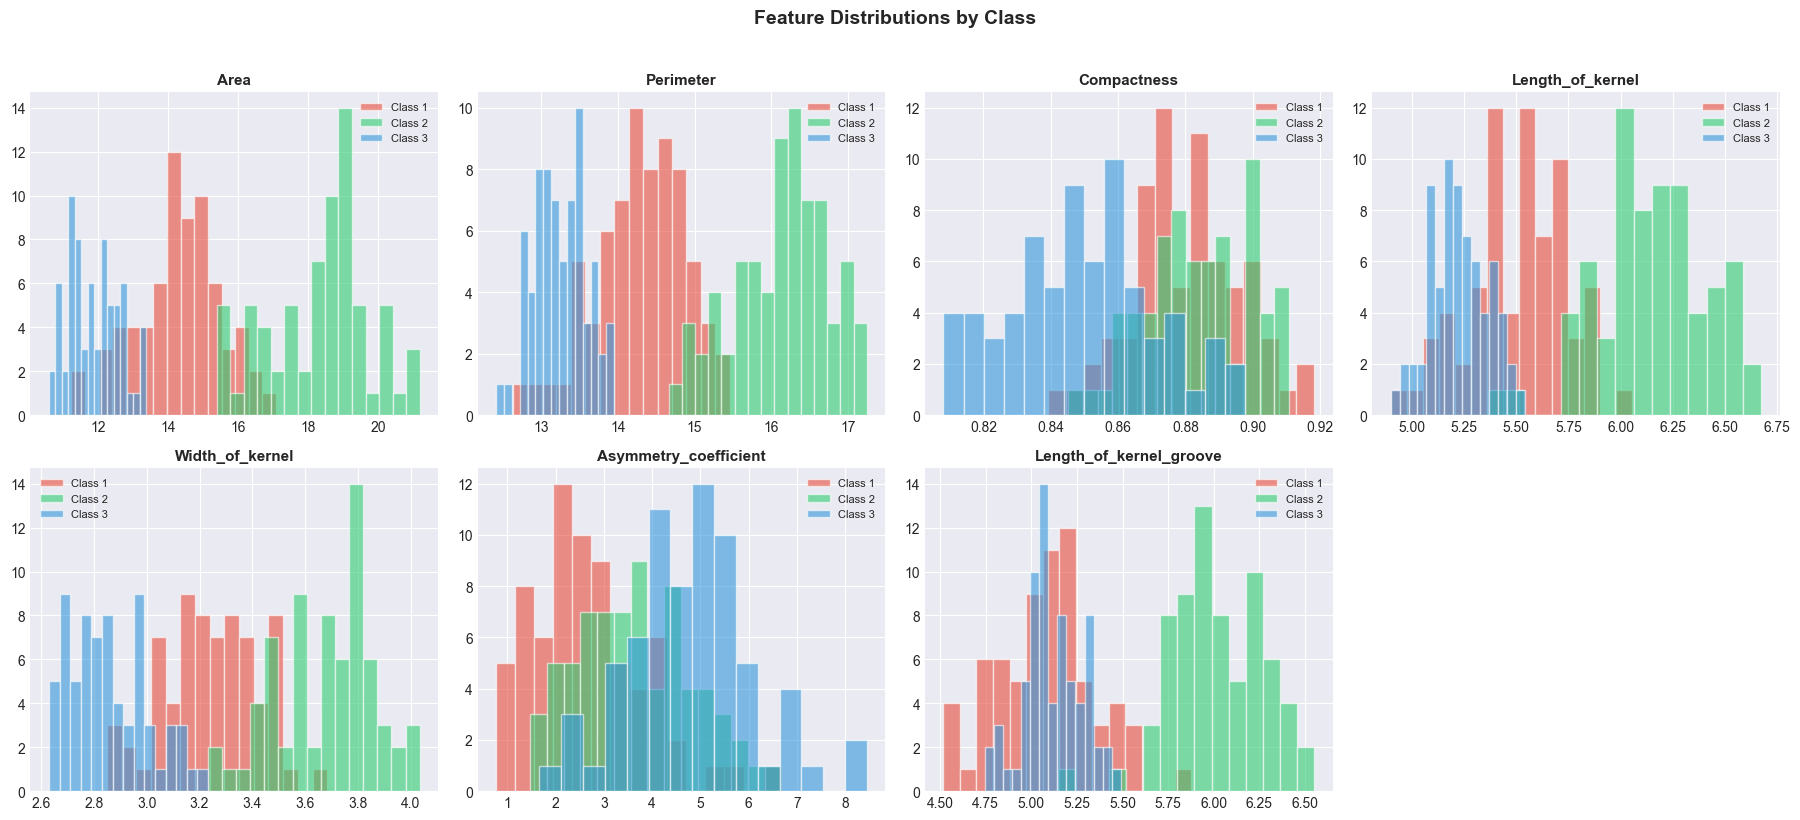

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ['#e74c3c', '#2ecc71', '#3498db']

for i, col in enumerate(feature_cols):
    for cls in sorted(df['Class'].unique()):
        axes[i].hist(df[df['Class'] == cls][col], bins=15, alpha=0.6,
                     label=f'Class {cls}', color=colors[cls-1], edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Correlation Heatmap

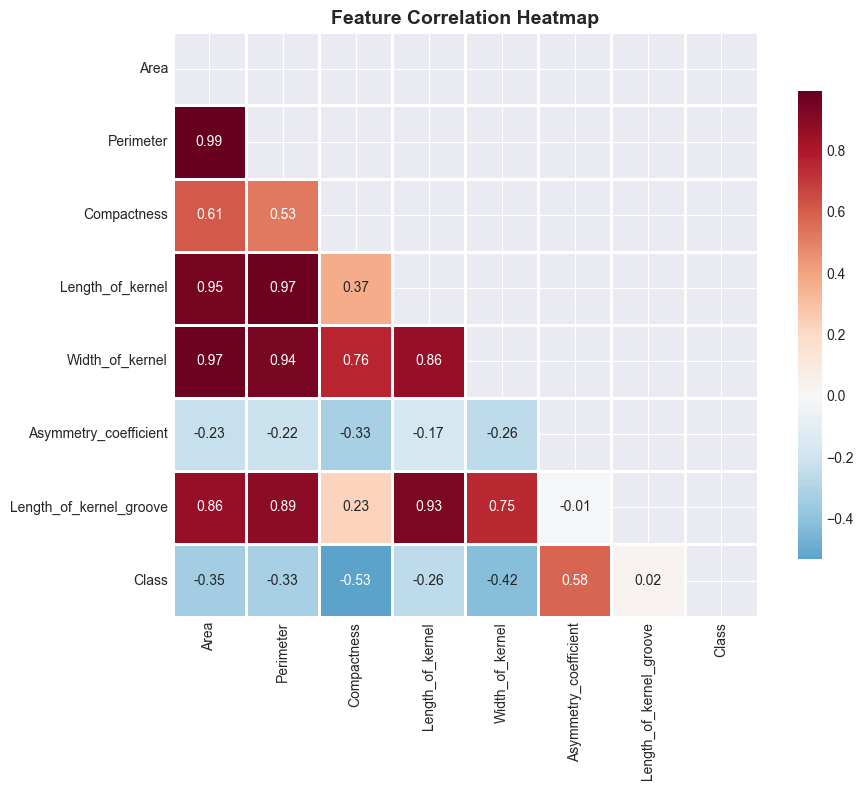

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Pair Plot

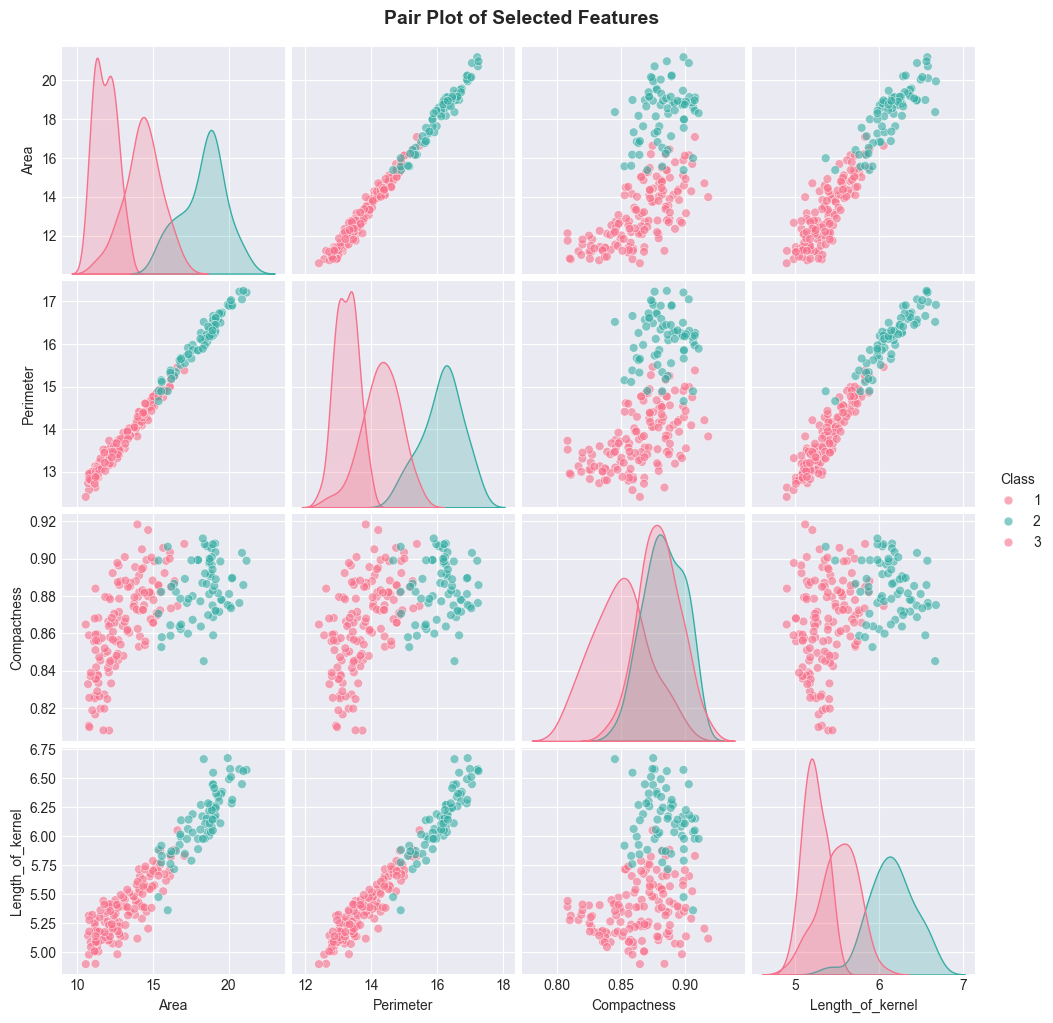

In [16]:
# Pair plot (using a subset of features for clarity)
selected_features = ['Area', 'Perimeter', 'Compactness', 'Length_of_kernel', 'Class']
pair_plot = sns.pairplot(df[selected_features], hue='Class', palette='husl',
                         diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
pair_plot.figure.suptitle('Pair Plot of Selected Features', fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 5.4 Class Distribution (Bar Chart & Pie Chart)

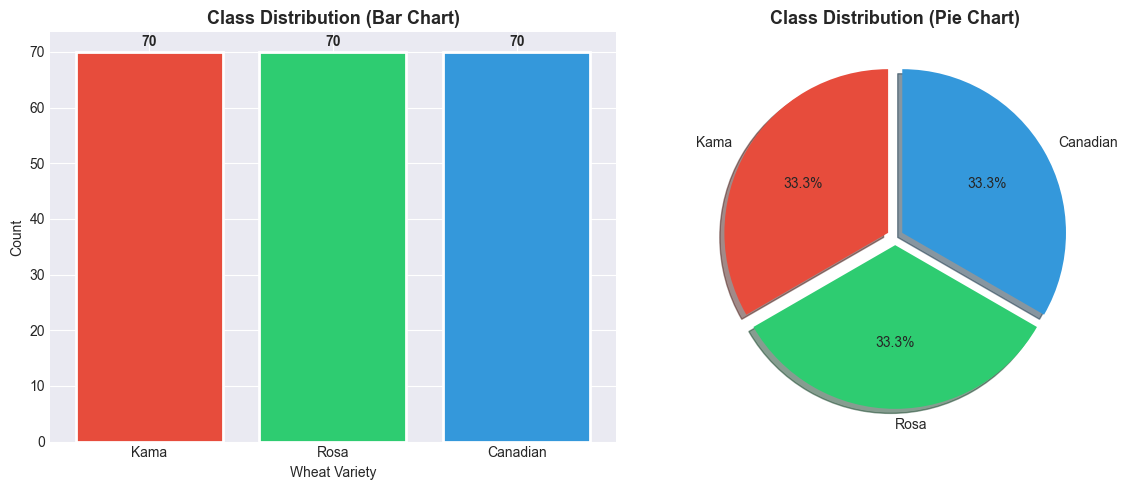

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_names = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
class_counts = df['Class'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar([class_names[c] for c in class_counts.index], class_counts.values,
                    color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='white', linewidth=2)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Wheat Variety')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=[class_names[c] for c in class_counts.index],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71', '#3498db'],
            startangle=90, explode=(0.05, 0.05, 0.05), shadow=True)
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.5 Violin Plots

/var/folders/kp/fw198wkx4r12hs00dmd89psm0000gn/T/ipykernel_88484/2572542029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Class', y=col, ax=axes[i], palette='husl', inner='box')
/var/folders/kp/fw198wkx4r12hs00dmd89psm0000gn/T/ipykernel_88484/2572542029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Class', y=col, ax=axes[i], palette='husl', inner='box')
/var/folders/kp/fw198wkx4r12hs00dmd89psm0000gn/T/ipykernel_88484/2572542029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Class'

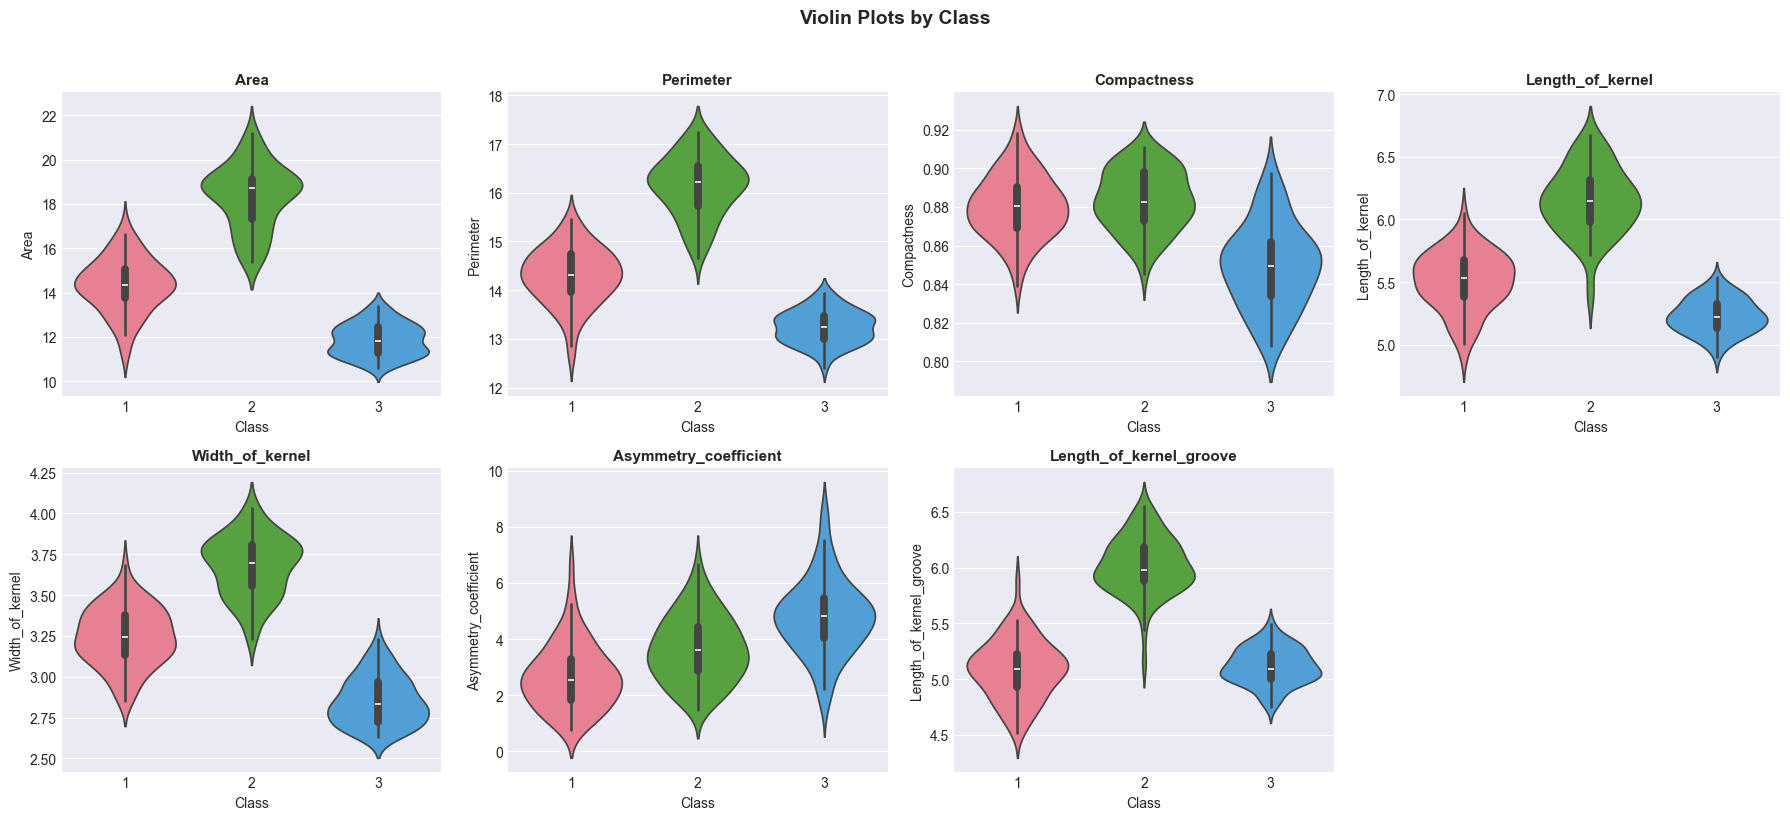

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.violinplot(data=df, x='Class', y=col, ax=axes[i], palette='husl', inner='box')
    axes[i].set_title(col, fontsize=11, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Violin Plots by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.6 Scatter Plot (Area vs Perimeter)

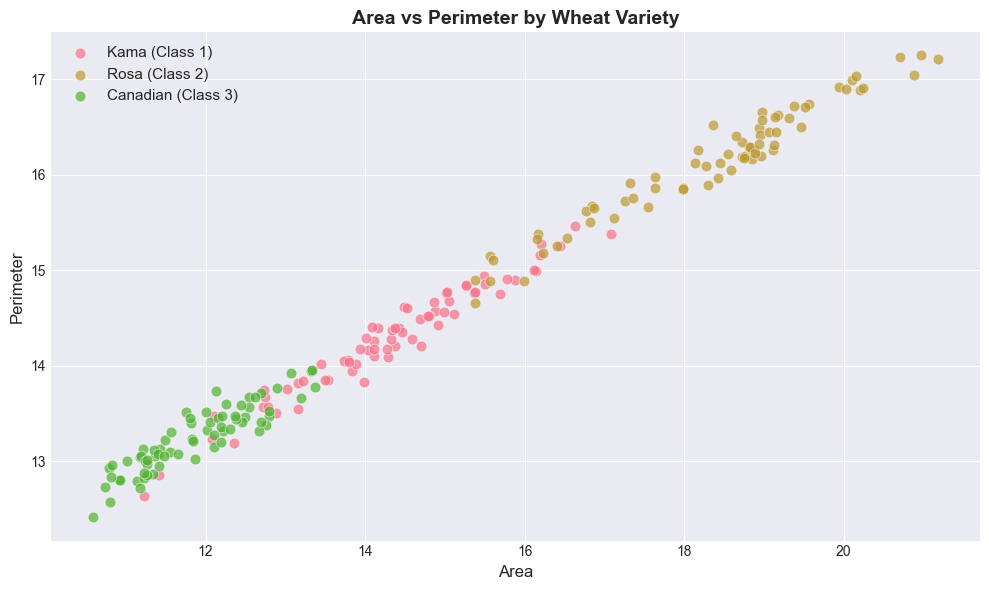

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

for cls in sorted(df['Class'].unique()):
    subset = df[df['Class'] == cls]
    ax.scatter(subset['Area'], subset['Perimeter'], label=f'{class_names[cls]} (Class {cls})',
               alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Area', fontsize=12)
ax.set_ylabel('Perimeter', fontsize=12)
ax.set_title('Area vs Perimeter by Wheat Variety', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 6. Conclusion
In this lab, we:
- **Cleaned** the dataset: checked for missing values, duplicates, and outliers
- **Preprocessed** the data: applied StandardScaler and MinMaxScaler normalization, performed train-test split
- **Visualized** the data using histograms, correlation heatmap, pair plots, box plots, violin plots, bar/pie charts, and scatter plots
- The dataset is **balanced** (70 samples per class) and ready for machine learning